# Homework 2: Stochastic Gradient Descent

```{warning}
The submission of the homeworks has **NO** deadline. You can submit them whenever you want, on Virtuale. You are only required to upload it on Virtuale **BEFORE** your exam session, since the Homeworks will be a central part of the oral exam. 

You are asked to submit the homework as one of the two, following modalities:
* A PDF (or Word) document, containing screenshoots of code snippets, screeshots of the results generated by your code, and a brief comment on the obtained results.
* A Python Notebook (i.e. a `.ipynb` file), with cells containing the code required to solve the indicated exercises, alternated with a brief comment on the obtained results in the form of a markdown cell. We remark that the code **SHOULD NOT** be runned during the exam, but the student is asked to enter the exam with all the programs **already executed**, with the results clearly visible on the screen.

Joining the oral exam with a non-executed code OR without a PDF file with the obtained results visible on that, will cause the student to be rejected.
```

## Exercise 1: SGD vs GD on a Simple 1D Regression Problem

Consider the synthetic dataset

$$
x^{(i)} = \frac{i}{N},\qquad
y^{(i)} = 2x^{(i)} + 1 + \varepsilon^{(i)}, \qquad \varepsilon^{(i)}\sim\mathcal N(0,0.01),
$$

with $N = 200$.
We model the data with a linear function:

$$
f_\Theta(x) = \Theta_0 + \Theta_1 x = \Theta^T \tilde{x},
$$

if we define $\tilde{x} = [1, x]$ as we did during the lab session.


1. Implement the MSE loss:
   
   $$
   \mathcal L(\Theta)=\frac{1}{N}\sum_{i=1}^N (f_\Theta(x^{(i)}) - y^{(i)})^2.
   $$


2. Implement **full GD** and **SGD** (mini-batch) using batch sizes:
   - $N_{\text{batch}} = 1$,
   - $N_{\text{batch}} = 10$,
   - $N_{\text{batch}} = 50$,
   - $N_{\text{batch}} = N$ (this recovers GD).

3. Plot for each method:
   - the loss curve (loss vs epoch),
   - the trajectory of parameters $(\Theta_0,\Theta_1)$ in the 2D parameter space. This is similar to what you did in the previous homework: simply plot the value of $\Theta_0^{(k)}$ and $\Theta_1^{(k)}$ for all the $k$s in a 2-dimensional plot.

4. Discuss:
   - Why GD is smooth but slow for large $N$,
   - Why SGD is noisy but progresses faster,
   - How batch size affects the noise level and convergence stability.


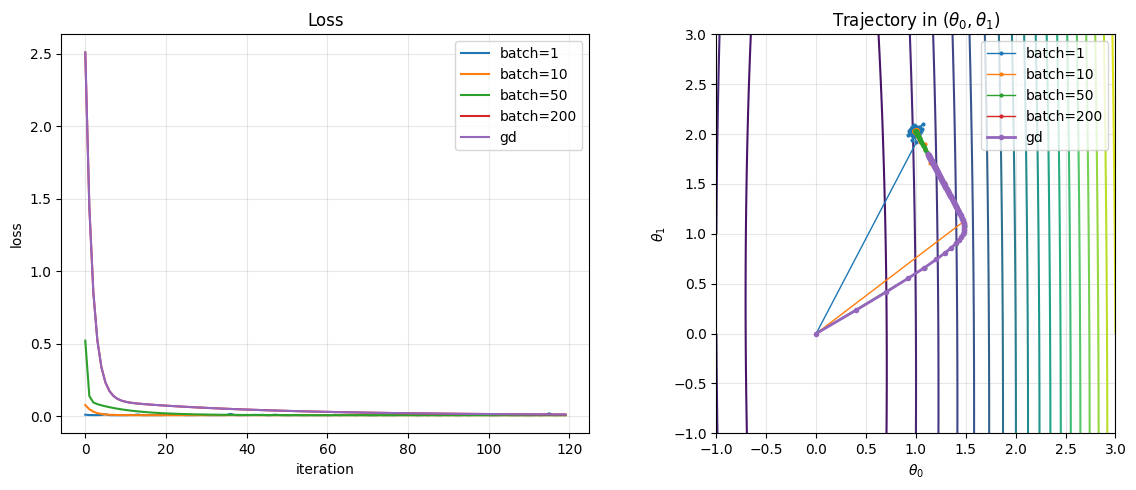

1 [1.02889345 2.01306848] 0.008836060229619348
10 [0.99691255 2.0354951 ] 0.008200782000952256
50 [0.99363662 2.03170682] 0.008185763065634124
200 [1.12170365 1.79577901] 0.012994236031489623
gd [1.12170365 1.79577901] 0.012994236031489631


In [10]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(1)
N = 200
x = np.arange(1, N + 1)/N
y = 2*x + 1 + np.random.normal(0, np.sqrt(0.01), size=N)
X = np.column_stack([np.ones(N), x])
Y = y.reshape(-1, 1)

def l(theta, X, Y):
    r = X @ theta - Y
    return np.mean(r**2)

def grad_l(theta, X, Y):
    return (2/len(Y))*X.T @ (X @ theta - Y)

def sgd(l, grad_l, theta0, X, Y, batch_size, lr=0.1, epochs=80):
    theta = theta0.copy()
    losses = []
    path = [theta.ravel().copy()]
    n = len(Y)
    for epoch in range(epochs):
        idx = np.random.permutation(n)
        for start in range(0, n, batch_size):
            batch = idx[start:start + batch_size]
            theta = theta - lr*grad_l(theta, X[batch], Y[batch])
        losses.append(l(theta, X, Y))
        path.append(theta.ravel().copy())
    return theta, np.array(losses), np.array(path)

def gd(l, grad_l, theta0, X, Y, lr=0.1, epochs=80):
    theta = theta0.copy()
    losses = []
    path = [theta.ravel().copy()]
    for epoch in range(epochs):
        theta = theta - lr*grad_l(theta, X, Y)
        losses.append(l(theta, X, Y))
        path.append(theta.ravel().copy())
    return theta, np.array(losses), np.array(path)


def quad_levelsets(A, xlim=(-1, 1), ylim=(-1, 1), ngrid=100, ncontours=20, ax=None):
    if ax is None:
        ax = plt.gca()
    xs = np.linspace(xlim[0], xlim[1], ngrid)
    ys = np.linspace(ylim[0], ylim[1], ngrid)
    X, Y = np.meshgrid(xs, ys)
    Z = 0.5*(A[0,0]*X**2 + 2*A[0,1]*X*Y + A[1,1]*Y**2)
    ax.contour(X, Y, Z, levels=ncontours)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_aspect("equal")
    return ax



batch_sizes = [1, 10, 50, N]
results = {}
for batch_size in batch_sizes:
    np.random.seed(12)
    results[batch_size] = sgd(l, grad_l, np.zeros((2, 1)), X, Y, batch_size=batch_size, lr=0.1, epochs=120)
results["gd"] = gd(l, grad_l, np.zeros((2, 1)), X, Y, lr=0.1, epochs=120)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Loss curves
for batch_size in batch_sizes:
    theta, losses, path = results[batch_size]
    axes[0].plot(losses, label=f"batch={batch_size}")

theta, losses, path = results["gd"]
axes[0].plot(losses, label="gd")

axes[0].set_title("Loss")
axes[0].set_xlabel("iteration")
axes[0].set_ylabel("loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)


# Theta trajectory over level sets
quad_levelsets(X, xlim=(-1, 3), ylim=(-1, 3), ax=axes[1])

for batch_size in batch_sizes:
    theta, losses, path = results[batch_size]
    axes[1].plot(
        path[:, 0],
        path[:, 1],
        "o-",
        markersize=2,
        linewidth=1,
        label=f"batch={batch_size}",
    )

theta, losses, path = results["gd"]
axes[1].plot(
    path[:, 0],
    path[:, 1],
    "o-",
    markersize=3,
    linewidth=2,
    label="gd",
)

axes[1].set_title(r"Trajectory in $(\theta_0, \theta_1)$")
axes[1].set_xlabel(r"$\theta_0$")
axes[1].set_ylabel(r"$\theta_1$")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


for batch_size in batch_sizes:
    theta, losses, path = results[batch_size]
    print(batch_size, theta.ravel(), losses[-1])
theta, losses, path = results["gd"]
print("gd", theta.ravel(), losses[-1])


## Exercise 2: Variance of the Stochastic Gradient (1D Experiment)

Fix a parameter vector $\Theta$, and repeatedly draw random mini-batches of the same size.

1. Choose batch sizes:
   
   $$
   N_{\text{batch}} \in \{1, 5, 20, N\}.
   $$


2. At the **same** $\Theta$, compute:
   
   $$
   g_k = \nabla_\Theta \mathcal L(\Theta; \mathcal M_k)
   $$

   for 100 randomly sampled batches $\mathcal M_k$.

3. For each batch size, compute the empirical variance:
   
   $$
   \mathrm{Var}(g) = \frac{1}{100}\sum_{k=1}^{100} \|g_k - \bar g\|^2,
   $$

   where $\bar{g}$ is the average of the $g_k$s, defined as:

   $$
   \bar{g} = \frac{1}{100} \sum_{k=1}^{100} g_k.
   $$


4. Plot the variance as a function of the batch size.

5. Comment:
   - Why the variance decreases with larger batches,
   - Why SGD becomes more stable as $N_{\text{batch}}$ increases,
   - The trade-off between stability and computational cost.


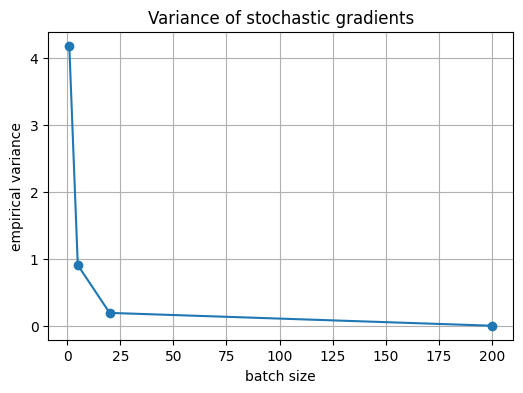

1 4.177547021037111 [-3.90845879 -2.15652149]
5 0.9048800011808253 [-3.93781552 -2.21577639]
20 0.19148888363235442 [-3.9693749  -2.26957938]
200 6.267894322433549e-29 [-4.03133776 -2.3647826 ]


In [2]:
import numpy as np
import matplotlib.pyplot as plt

theta = np.zeros((2, 1))

batch_sizes = [1, 5, 20, N]
variances = []
means = []
for batch_size in batch_sizes:
    gradients = []
    for k in range(100):
        idx = np.random.choice(N, size=batch_size, replace=False)
        gradients.append(grad_l(theta, X[idx], Y[idx]).ravel())
    gradients = np.array(gradients)
    gbar = gradients.mean(axis=0)
    variance = np.mean(np.sum((gradients - gbar)**2, axis=1))
    variances.append(variance)
    means.append(gbar)

plt.figure(figsize=(6, 4))
plt.plot(batch_sizes, variances, "o-")
plt.xlabel("batch size")
plt.ylabel("empirical variance")
plt.title("Variance of stochastic gradients")
plt.grid()
plt.show()

for batch_size, variance, mean in zip(batch_sizes, variances, means):
    print(batch_size, variance, mean)


## Exercise 3: SGD in 2D

We now study SGD on the 2D non-convex function:

$$
\mathcal{L}(\Theta_1,\Theta_2) = (\Theta_1^2 - 1)^2 + 10(\Theta_2 - \Theta_1^2)^2.
$$

This function has:
- two valleys,
- multiple stationary points,
- strong curvature differences.

1. Treat $\Theta = (\Theta_1,\Theta_2)$ as a “parameter vector” updated by SGD:
   
   $$
   \Theta_{k+1} = \Theta_k - \eta\, g_k,
   $$

   where the ``gradient batch'' $g_k$ is simulated by adding noise to the gradient:
   
   $$
   g_k = \nabla \mathcal{L}(\Theta_k) + \varepsilon_k, \qquad \varepsilon_k \sim \mathcal{N}(0, \sigma^2I),
   $$

   where $\sigma^2$ is called **noise level** and represent the variance of the noise. Try different values of $\sigma^2$ to answer the following questions. *Note: $\sigma^2$ should always be lower than 1*. 

2. Plot:
   - level sets of $\mathcal{L}(\Theta_1,\Theta_2)$,
   - trajectories of SGD for different noise levels and step sizes.

3. Discuss:
   - How noise helps escape shallow minima or bad regions,
   - How too much noise prevents convergence,


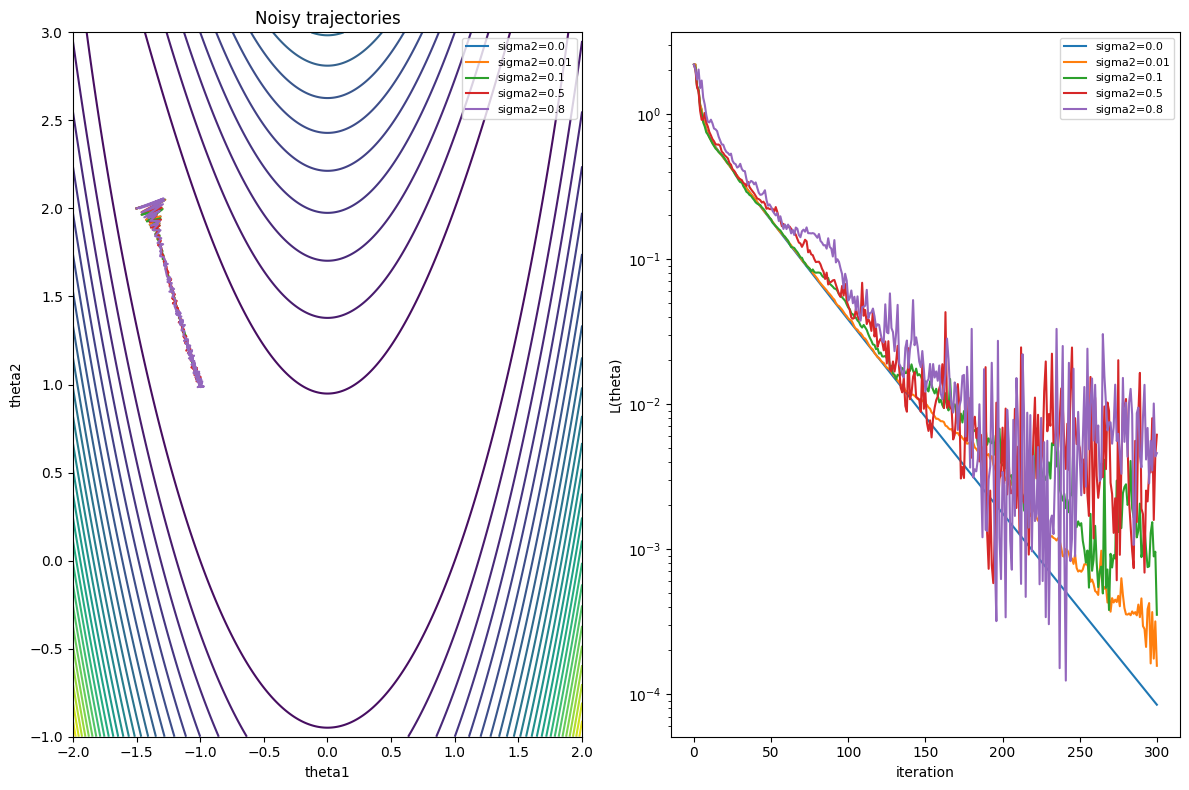

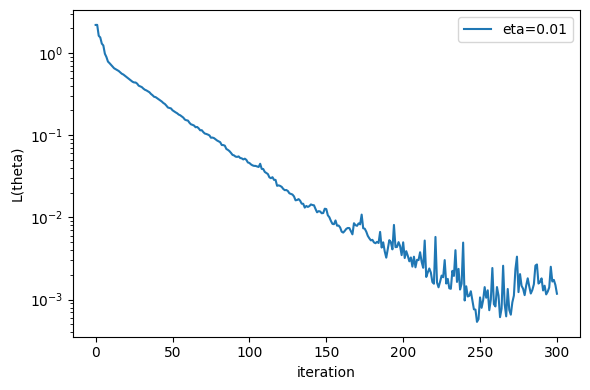

eta trials {0.01: 0.0004172079099506622}
selected eta 0.01
0.0 [-1.0044395  1.0096227] 8.442865708879275e-05
0.01 [-1.00486     1.00915158] 9.844323902491903e-05
0.1 [-0.99647383  0.99799476] 0.0003030384722798536
0.5 [-1.01322657  1.05596383] 0.009314919891567878
0.8 [-0.96880569  0.95621667] 0.0068808196546918145


In [3]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(2)

def L(theta):
    x, y = theta
    return (x**2 - 1)**2 + 10*(y - x**2)**2

def grad_L(theta):
    x, y = theta
    return np.array([4*x*(x**2 - 1) - 40*x*(y - x**2), 20*(y - x**2)])

def noisy_gd(theta0, eta, sigma2, epochs=300):
    theta = theta0.astype(float).copy()
    path = [theta.copy()]
    losses = [L(theta)]
    for k in range(epochs):
        noise = np.random.normal(0, np.sqrt(sigma2), size=2)
        theta = theta - eta*(grad_L(theta) + noise)
        path.append(theta.copy())
        losses.append(L(theta))
    return np.array(path), np.array(losses)

theta = np.array([-1.5, 2.0])
eta_values = [0.01]
eta_scores = {}
for eta in eta_values:
    path, losses = noisy_gd(theta, eta=eta, sigma2=0.01, epochs=300)
    eta_scores[eta] = float(losses[-1])
selected_eta = min(eta_scores, key=eta_scores.get)

xs = np.linspace(-2, 2, 400)
ys = np.linspace(-1, 3, 400)
Xg, Yg = np.meshgrid(xs, ys)
Z = (Xg**2 - 1)**2 + 10*(Yg - Xg**2)**2
noise_levels = [0.0, 0.01, 0.1, 0.5,0.8]
fig, axes = plt.subplots(1, 2, figsize=(12, 8))
axes[0].contour(Xg, Yg, Z, levels=30)
for sigma2 in noise_levels:
    path, losses = noisy_gd(theta, eta=selected_eta, sigma2=sigma2)
    axes[0].plot(path[:,0], path[:,1], label=f"sigma2={sigma2}")
    axes[1].semilogy(losses, label=f"sigma2={sigma2}")
axes[0].set_xlabel("theta1")
axes[0].set_ylabel("theta2")
axes[0].set_title("Noisy trajectories")
axes[0].legend(fontsize=8)
axes[1].set_xlabel("iteration")
axes[1].set_ylabel("L(theta)")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
for eta in eta_values:
    path, losses = noisy_gd(theta, eta=eta, sigma2=0.1)
    plt.semilogy(losses, label=f"eta={eta}")
plt.xlabel("iteration")
plt.ylabel("L(theta)")
plt.legend()
plt.tight_layout()
plt.show()


print("eta trials", eta_scores)
print("selected eta", selected_eta)
for sigma2 in noise_levels:
    path, losses = noisy_gd(theta, eta=selected_eta, sigma2=sigma2)
    print(sigma2, path[-1], losses[-1])


## Exercise 4: An ML Project with SGD

For the final exercise, you will train a simple machine learning model using SGD on a real prediction task. 
To begin, download the Kaggle dataset: https://www.kaggle.com/datasets/mirichoi0218/insurance.

It contains approximately 1300 samples, and its associated task is to predict **individual medical insurance cost** based on numerical features:

- `age`
- `bmi`
- `children`  

The task is:

$$
\text{charges} \approx f_\Theta(\text{age},\text{bmi},\text{children}).
$$

We use a simple linear model:

$$
f_\Theta(x) = \Theta^T \tilde{x}.
$$

1. Load & preprocess the dataset
   - Download `insurance.csv` from Kaggle.
   - Select numerical columns:  
     `["age", "bmi", "children"]`.
   - Standardize each feature (mean 0, variance 1).
   - Standardize the target `"charges"`.
   - Add a bias column.
  
2. Consider the MSE loss:

   $$
   \mathcal{L}(\Theta)=\frac{1}{N}\sum_{i=1}^N (\Theta^T \tilde{x}^{(i)} - \tilde{y}^{(i)})^2.
   $$

   Implement:
   - Full GD  
   - SGD with batch sizes 1, 10, 50

   Use a fixed learning rate $\eta=10^{-2}$ and a fixed number of epochs (equivalently, a fixed amount of maximum iterations for GD) of your choice.

3. Compare GD and SGD
   For each method:

   - Plot the loss vs epoch.
   - Plot the L2 norm of the **full gradient** $\|\nabla \mathcal{L}(\Theta_k)\|$ measured at the end of every epoch.
   - Report the final learned parameters.

4. Discuss:
   - Why GD gives a smooth curve and SGD oscillates.
   - Why larger batches reduce noise but cost more per iteration.
   - Why all methods roughly converge to the same region.
   - Why SGD is more suitable for large datasets, even when noisy.


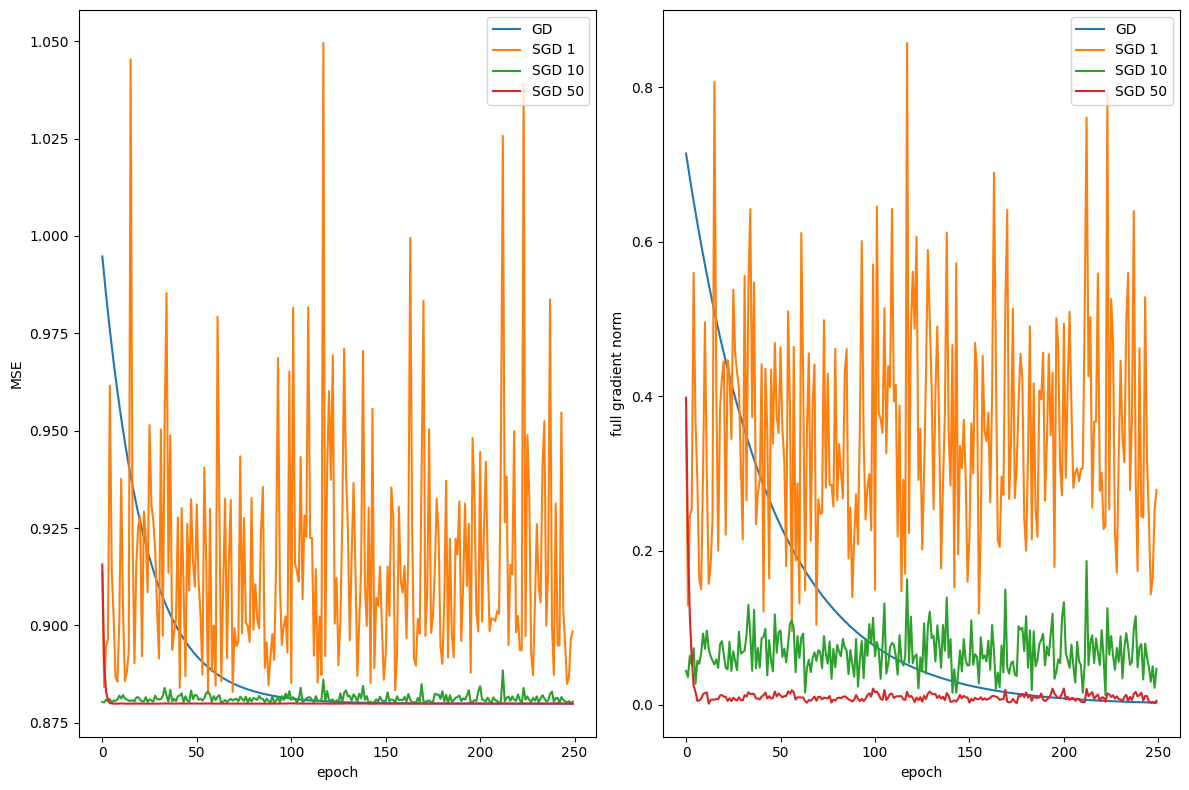

method                                                     theta      final_loss    final_grad_norm
----------------------------------------------------------------------------------------------------
GD                         [0.       0.277033 0.167028 0.054069]        0.879904       2.941740e-03
SGD 1                  [-0.072417  0.256736  0.069233  0.003656]        0.898442       2.785872e-01
SGD 10                     [0.003447 0.273548 0.145719 0.056553]        0.880427       4.696138e-02
SGD 50                 [-0.00052   0.2786    0.164616  0.053526]        0.879909       5.417947e-03


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

np.random.seed(3)

def load_insurance():
    path = Path("insurance.csv")
    df = pd.read_csv(path)
    return df[["age", "bmi", "children"]].values, df["charges"].values.reshape(-1, 1)
   

X_raw, Y_raw = load_insurance()
X_scaled = (X_raw - X_raw.mean(axis=0))/X_raw.std(axis=0)
Y_scaled = (Y_raw - Y_raw.mean(axis=0))/Y_raw.std(axis=0)
X_model = np.column_stack([np.ones(len(X_scaled)), X_scaled])

def l(theta, X, Y):
    return np.mean((X @ theta - Y)**2)

def grad_l(theta, X, Y):
    return (2/len(Y))*X.T @ (X @ theta - Y)

def train(theta0, X, Y, batch_size, lr=1e-2, epochs=250):
    theta = theta0.copy()
    losses = []
    grad_norms = []
    n = len(Y)
    for epoch in range(epochs):
        idx = np.random.permutation(n)
        for start in range(0, n, batch_size):
            batch = idx[start:start + batch_size]
            theta = theta - lr*grad_l(theta, X[batch], Y[batch])
        losses.append(l(theta, X, Y))
        grad_norms.append(np.linalg.norm(grad_l(theta, X, Y)))
    return theta, np.array(losses), np.array(grad_norms)


methods = {"GD": len(Y_scaled), "SGD 1": 1, "SGD 10": 10, "SGD 50": 50}
results = {}
for name, batch_size in methods.items():
    np.random.seed(30)
    results[name] = train(np.zeros((X_model.shape[1], 1)), X_model, Y_scaled, batch_size=batch_size, epochs=250)

fig, axes = plt.subplots(1, 2, figsize=(12, 8))
for name, (theta, losses, grad_norms) in results.items():
    axes[0].plot(losses, label=name)
    axes[1].plot(grad_norms, label=name)
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("MSE")
axes[0].legend()
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("full gradient norm")
axes[1].legend()
plt.tight_layout()
plt.show()



print(f"{'method':<18} {'theta':>45} {'final_loss':>15} {'final_grad_norm':>18}")
print("-" * 100)

for name, (theta, losses, grad_norms) in results.items():
    theta_str = np.array2string(
        np.asarray(theta).ravel(),
        precision=6,
        suppress_small=True,
    )

    print(
        f"{name:<18} "
        f"{theta_str:>45} "
        f"{losses[-1]:15.6f} "
        f"{grad_norms[-1]:18.6e}"
    )
